In [1]:
import sys
import os
from pathlib import Path
from typing import Optional
# sys.path.insert(0, str(Path(__file__).parent.parent))
sys.path.append(os.path.abspath("../"))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap

pd.set_option('display.max_columns', None)

import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("pipeline")

from sqlalchemy import (
    create_engine, text
)
from sqlalchemy.pool import StaticPool

from pipeline import load_features_for_ml, get_feature_columns
from models.nfl_forecaster import NFLPerformanceForecaster
from models.injury_risk import InjuryRiskModel
from models.college_translator import CollegeToNFLTranslator
from registry.model_store import ModelStore


In [2]:
current_path = os.getcwd()
DB_PATH = str(Path(current_path).parent / "dynasty_scout.db")
DB_PATH

'/Users/sandeeptiwari/Desktop/dynasty-ai-engine/dynasty_scout.db'

## Loading Data

In [3]:
df_all = load_features_for_ml(
    min_season=2015,          # 2016+ for NGS features
    max_season=2024,          # hold out 2024 for evaluation
    require_target=True,
    player_type="nfl",
)
df_all

01:15:15 [INFO] pipeline: Loaded 2862 rows for ML training (position=all, seasons=2015–2024)


,id,player_id,season,position,player_type,fantasy_ppg_ppr,fantasy_ppg_last_season,fantasy_ppg_2yr_avg,fantasy_ppg_3yr_avg,fantasy_ppg_trend,games_played,career_games,target_share,air_yards_share,wopr,snap_pct,snap_pct_trend,carries_per_game,targets_per_game,yards_per_target,yards_per_carry,yards_after_catch_per_rec,racr,epa_per_play,cpoe,ryoe_per_att,separation_avg,avg_yac_above_expectation,games_missed_last_season,games_missed_2yr_total,injury_risk_score,soft_tissue_injury_flag,acl_history_flag,concussion_history_count,injury_designation_count,age,age_at_nfl_entry,years_experience,age_vs_position_peak,team_pass_rate,team_pass_rate_neutral,team_plays_per_game,team_pass_attempts,team_points_per_game,offensive_line_rank,new_team_flag,new_oc_flag,scheme_fit_score,dominator_rating,breakout_age,college_yards_per_game,college_tds_per_game,college_conference_tier,draft_round,draft_pick_normalized,sparq_score,relative_athletic_score,speed_score,height_weight_bmi,forty_yard,vertical_jump,fantasy_ppg_next_season,player_name,nfl_team,sleeper_id,draft_year
2,3,00-0019596,2015,QB,nfl,21.543750,NaN,NaN,NaN,NaN,16.0,NaN,0.017857,0.012259,0.035367,0.989444,NaN,2.125000,0.062500,36.00000,1.558824,29.000000,5.142857,3.129031,NaN,NaN,NaN,NaN,0,0,0.000000,0,0,0,1,38.078029,23.080082,23,4.078029,0.6503,0.6693,65.78,770.0,29.06,11.0,0,0,0.50000,NaN,NaN,NaN,NaN,NaN,6.0,0.071966,NaN,NaN,NaN,NaN,NaN,NaN,21.546667,Tom Brady,None,None,2000.0
3,4,00-0019596,2016,QB,nfl,21.546667,21.543750,21.543750,21.543750,NaN,12.0,16.0,0.000000,0.000000,0.000000,0.972667,-0.016778,2.333333,0.000000,NaN,2.285714,NaN,NaN,NaN,3.269891,NaN,NaN,NaN,0,0,0.000000,0,0,0,4,39.080082,23.080082,23,5.080082,0.5640,0.5969,67.84,727.0,27.56,6.0,0,0,0.50000,NaN,NaN,NaN,NaN,NaN,6.0,0.071966,NaN,NaN,NaN,NaN,NaN,NaN,18.492500,Tom Brady,None,None,2000.0
4,5,00-0019596,2017,QB,nfl,18.492500,21.546667,21.545208,21.545208,0.002917,16.0,28.0,0.000000,0.000000,0.000000,0.980526,0.007860,1.562500,0.000000,NaN,1.120000,NaN,NaN,NaN,0.849809,NaN,NaN,NaN,0,0,0.000000,0,0,0,1,40.079398,23.080082,23,6.079398,0.5984,0.6057,67.63,769.0,28.62,9.0,0,0,0.50000,NaN,NaN,NaN,NaN,NaN,6.0,0.071966,NaN,NaN,NaN,NaN,NaN,NaN,17.581250,Tom Brady,None,None,2000.0
5,6,00-0019596,2018,QB,nfl,17.581250,18.492500,20.019583,20.527639,-1.525625,16.0,44.0,0.025000,0.000000,0.037500,1.000000,0.019474,1.437500,0.062500,6.00000,1.521739,6.000000,NaN,-0.220586,-1.562972,NaN,NaN,NaN,0,0,0.000000,0,0,0,1,41.078713,23.080082,23,7.078713,0.5633,0.5658,66.89,716.0,32.94,6.0,1,1,0.50000,NaN,NaN,NaN,NaN,NaN,6.0,0.071966,NaN,NaN,NaN,NaN,NaN,NaN,16.480000,Tom Brady,None,None,2000.0
6,7,00-0019596,2019,QB,nfl,16.480000,17.581250,18.036875,19.206806,-1.982708,16.0,60.0,0.000000,0.000000,0.000000,0.988235,-0.011765,1.625000,0.000000,NaN,1.307692,NaN,NaN,NaN,-2.997041,NaN,NaN,NaN,0,0,0.000000,0,0,0,1,42.078029,23.080082,23,8.078029,0.5933,0.6040,68.12,687.0,26.25,3.0,1,1,0.50000,NaN,NaN,NaN,NaN,NaN,6.0,0.071966,NaN,NaN,NaN,NaN,NaN,NaN,21.120000,Tom Brady,None,None,2000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5487,5488,00-0039146,2023,WR,nfl,13.575000,NaN,6.836364,6.836364,NaN,16.0,NaN,2.827228,3.255236,6.519507,0.558889,NaN,0.687500,5.875000,8.43617,10.818182,5.234375,0.817526,0.354247,NaN,NaN,3.444668,0.284881,0,0,0.000000,0,0,0,3,23.342916,23.342916,4,-2.657084,0.5707,0.5354,61.79,670.0,22.53,3.0,0,0,1.00000,0.340734,20.344969,78.923077,0.769231,1.0,2.0,0.314135,70.645825,9.468991,95.374343,26.078357,4.45,33.5,11.588235,Jayden Reed,None,None,2023.0
5489,5490,00-0039150,2023,QB,nfl,9.773750,NaN,13.575000,13.575000,NaN,16.0,NaN,0.000000,0.000000,0.000000,0.998125,NaN,2.437500,0.000000,NaN,6.487179,NaN,NaN,NaN,-1.574166,NaN,NaN,NaN,1,0,0.020588,0,0,0,1,22.102669,22.102669,4,-11.897331,0.5933,0.5399,64.65,652.0,13

In [4]:
print(f"  {len(df_all)} player-seasons loaded")
print(f"  Positions: {df_all['position'].value_counts().to_dict()}")
print(f"  Seasons: {sorted(df_all['season'].unique())}")
print(f"\nTarget variable distribution:")
print(df_all["fantasy_ppg_next_season"].describe().round(2))

  2862 player-seasons loaded
  Positions: {'WR': 1158, 'RB': 757, 'TE': 610, 'QB': 337}
  Seasons: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

Target variable distribution:
count    2862.00
mean        8.65
std         5.59
min        -1.40
25%         4.15
50%         7.67
75%        12.39
max        30.13
Name: fantasy_ppg_next_season, dtype: float64


## Data Quality
___
### NFL features

In [5]:
feat_config = get_feature_columns()
features_to_check = feat_config["nfl_features"]
missing_pct = (
    df_all[features_to_check]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
missing_pct.columns = ["feature", "missing_pct"]
# print("\nFeature missingness (top 10):")
print("\nNFL Feature missingness:")
# print(missing_pct.head(10).to_string())
print(missing_pct.to_string())


NFL Feature missingness:
                      feature  missing_pct
0                        cpoe     0.904263
1                ryoe_per_att     0.899022
2              separation_avg     0.677498
3   avg_yac_above_expectation     0.677498
4           fantasy_ppg_trend     0.489867
5             yards_per_carry     0.363033
6              snap_pct_trend     0.278826
7     fantasy_ppg_last_season     0.269043
8                career_games     0.269043
9                        racr     0.101328
10  yards_after_catch_per_rec     0.099581
11           yards_per_target     0.095038
12               epa_per_play     0.095038
13        fantasy_ppg_2yr_avg     0.052061
14     team_pass_rate_neutral     0.035290
15             team_pass_rate     0.035290
16        offensive_line_rank     0.035290
17       team_points_per_game     0.035290
18         team_pass_attempts     0.035290
19        team_plays_per_game     0.035290
20        fantasy_ppg_3yr_avg     0.014675
21                   snap_pc

### College Features

In [6]:
feat_config = get_feature_columns()
features_to_check = feat_config["college_features"]
missing_pct = (
    df_all[features_to_check]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
missing_pct.columns = ["feature", "missing_pct"]
# print("\nFeature missingness (top 10):")
print("\nCollege Feature missingness:")
# print(missing_pct.head(10).to_string())
print(missing_pct.to_string())


College Feature missingness:
                    feature  missing_pct
0              breakout_age     0.714535
1               sparq_score     0.705101
2             vertical_jump     0.577568
3               speed_score     0.551712
4                forty_yard     0.549965
5    college_yards_per_game     0.547170
6      college_tds_per_game     0.547170
7   relative_athletic_score     0.500000
8          dominator_rating     0.387142
9   college_conference_tier     0.357442
10    draft_pick_normalized     0.215584
11              draft_round     0.211041
12                      age     0.000000
13         age_at_nfl_entry     0.000000
14         years_experience     0.000000
15     age_vs_position_peak     0.000000


### Performance Features

In [7]:
feat_config = get_feature_columns()
features_to_check = feat_config["performance"]
missing_pct = (
    df_all[features_to_check]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
missing_pct.columns = ["feature", "missing_pct"]
# print("\nFeature missingness (top 10):")
print("\Performance Feature missingness:")
# print(missing_pct.head(10).to_string())
print(missing_pct.to_string())

\Performance Feature missingness:
                   feature  missing_pct
0        fantasy_ppg_trend     0.489867
1  fantasy_ppg_last_season     0.269043
2             career_games     0.269043
3      fantasy_ppg_2yr_avg     0.052061
4      fantasy_ppg_3yr_avg     0.014675
5             games_played     0.000000


### Role Features

In [8]:
feat_config = get_feature_columns()
features_to_check = feat_config["role"]
missing_pct = (
    df_all[features_to_check]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
missing_pct.columns = ["feature", "missing_pct"]
# print("\nFeature missingness (top 10):")
print("\Role Feature missingness:")
# print(missing_pct.head(10).to_string())
print(missing_pct.to_string())

\Role Feature missingness:
            feature  missing_pct
0    snap_pct_trend     0.278826
1          snap_pct     0.009434
2      target_share     0.000000
3   air_yards_share     0.000000
4              wopr     0.000000
5  carries_per_game     0.000000
6  targets_per_game     0.000000


### Efficiency

In [9]:
feat_config = get_feature_columns()
features_to_check = feat_config["efficiency"]
missing_pct = (
    df_all[features_to_check]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
missing_pct.columns = ["feature", "missing_pct"]
# print("\nFeature missingness (top 10):")
print("\Efficiency Feature missingness:")
# print(missing_pct.head(10).to_string())
print(missing_pct.to_string())

\Efficiency Feature missingness:
                     feature  missing_pct
0                       cpoe     0.904263
1               ryoe_per_att     0.899022
2             separation_avg     0.677498
3  avg_yac_above_expectation     0.677498
4            yards_per_carry     0.363033
5                       racr     0.101328
6  yards_after_catch_per_rec     0.099581
7           yards_per_target     0.095038
8               epa_per_play     0.095038


### Injury

In [10]:
feat_config = get_feature_columns()
features_to_check = feat_config["injury"]
missing_pct = (
    df_all[features_to_check]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
missing_pct.columns = ["feature", "missing_pct"]
# print("\nFeature missingness (top 10):")
print("\Injury Feature missingness:")
# print(missing_pct.head(10).to_string())
print(missing_pct.to_string())

\Injury Feature missingness:
                    feature  missing_pct
0  games_missed_last_season          0.0
1    games_missed_2yr_total          0.0
2         injury_risk_score          0.0
3   soft_tissue_injury_flag          0.0
4          acl_history_flag          0.0
5  concussion_history_count          0.0


### Age Curve

In [11]:
feat_config = get_feature_columns()
features_to_check = feat_config["age_curve"]
missing_pct = (
    df_all[features_to_check]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
missing_pct.columns = ["feature", "missing_pct"]
# print("\nFeature missingness (top 10):")
print("\Age Curve Feature missingness:")
# print(missing_pct.head(10).to_string())
print(missing_pct.to_string())

\Age Curve Feature missingness:
                feature  missing_pct
0                   age          0.0
1      age_at_nfl_entry          0.0
2      years_experience          0.0
3  age_vs_position_peak          0.0


### Team Context

In [12]:
feat_config = get_feature_columns()
features_to_check = feat_config["team_context"]
missing_pct = (
    df_all[features_to_check]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
missing_pct.columns = ["feature", "missing_pct"]
# print("\nFeature missingness (top 10):")
print("\Team Context Feature missingness:")
# print(missing_pct.head(10).to_string())
print(missing_pct.to_string())

\Team Context Feature missingness:
                  feature  missing_pct
0          team_pass_rate      0.03529
1  team_pass_rate_neutral      0.03529
2     team_plays_per_game      0.03529
3      team_pass_attempts      0.03529
4    team_points_per_game      0.03529
5     offensive_line_rank      0.03529
6           new_team_flag      0.00000
7             new_oc_flag      0.00000
8        scheme_fit_score      0.00000


### Prospect

In [13]:
feat_config = get_feature_columns()
features_to_check = feat_config["prospect"]
missing_pct = (
    df_all[features_to_check]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
missing_pct.columns = ["feature", "missing_pct"]
# print("\nFeature missingness (top 10):")
print("\Prospect Feature missingness:")
# print(missing_pct.head(10).to_string())
print(missing_pct.to_string())

\Prospect Feature missingness:
                    feature  missing_pct
0              breakout_age     0.714535
1               sparq_score     0.705101
2             vertical_jump     0.577568
3               speed_score     0.551712
4                forty_yard     0.549965
5    college_yards_per_game     0.547170
6      college_tds_per_game     0.547170
7   relative_athletic_score     0.500000
8          dominator_rating     0.387142
9   college_conference_tier     0.357442
10    draft_pick_normalized     0.215584
11              draft_round     0.211041


### Target

In [14]:
feat_config = get_feature_columns()
features_to_check = feat_config["target"]
missing_pct = (
    df_all[[features_to_check]]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
missing_pct.columns = ["feature", "missing_pct"]
# print("\nFeature missingness (top 10):")
print("\Target Feature missingness:")
# print(missing_pct.head(10).to_string())
print(missing_pct.to_string())

\Target Feature missingness:
                   feature  missing_pct
0  fantasy_ppg_next_season          0.0


## NFL Forecaster Model

In [15]:
wr_model = NFLPerformanceForecaster("WR")
wr_metrics = wr_model.train_with_tracking(
    df_all,
    params={"position": "WR", "model": "LightGBM"}
)
print(f"\nMetrics:")
for k, v in wr_metrics.items():
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

01:15:18 [INFO] models.nfl_forecaster: [WR] TimeSeriesCV MAE: 2.69 PPG (4 folds)
01:15:23 [INFO] models.base: Model saved to /Users/sandeeptiwari/Desktop/dynasty-ai-engine/models/registry/nfl_forecaster_wr.joblib
01:15:23 [INFO] models.base: [nfl_forecaster_wr] Training complete. Metrics: {'cv_mae': 2.686812160886141, 'train_mae': 0.6350081134201564, 'train_rmse': 0.8099189995212813, 'n_train': 1158, 'n_features': 39}



Metrics:
  cv_mae: 2.687
  train_mae: 0.635
  train_rmse: 0.810
  n_train: 1158
  n_features: 39


In [16]:
df_all.isna().mean().sort_values(ascending=False)[:10]

sleeper_id                   1.000000
nfl_team                     1.000000
cpoe                         0.904263
ryoe_per_att                 0.899022
breakout_age                 0.714535
sparq_score                  0.705101
separation_avg               0.677498
avg_yac_above_expectation    0.677498
vertical_jump                0.577568
speed_score                  0.551712
dtype: float64

### Features Importance


Top 15 features by LightGBM gain importance:
                      feature  importance
0         fantasy_ppg_2yr_avg         429
1                         age         428
2        team_points_per_game         415
3     fantasy_ppg_last_season         388
4                epa_per_play         388
5            age_at_nfl_entry         372
6             yards_per_carry         363
7          team_pass_attempts         362
8              team_pass_rate         359
9            targets_per_game         354
10                       racr         351
11  avg_yac_above_expectation         348
12        fantasy_ppg_3yr_avg         341
13                   snap_pct         341
14           yards_per_target         339


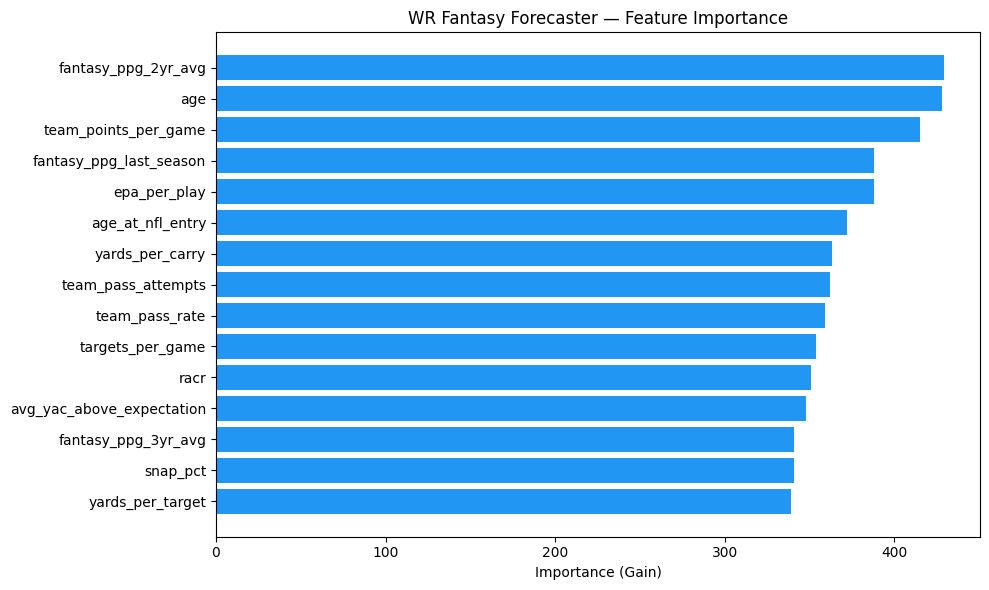

Saved: wr_feature_importance.png


In [17]:
importance_df = wr_model.get_feature_importance()
print("\nTop 15 features by LightGBM gain importance:")
print(importance_df.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
top15 = importance_df.head(15)
ax.barh(top15["feature"][::-1], top15["importance"][::-1], color="#2196F3")
ax.set_xlabel("Importance (Gain)")
ax.set_title("WR Fantasy Forecaster — Feature Importance")
plt.tight_layout()
plt.savefig("wr_feature_importance.png", dpi=150)
plt.show()
print("Saved: wr_feature_importance.png")

### SHAP waterfall for a single player
___
Let's explain the model's prediction for a specific player-season. SHAP shows exactly which features are pushing the prediction up or down.

In [18]:
wr_df = df_all[df_all["position"] == "WR"].sort_values("fantasy_ppg_ppr", ascending=False)

# Pick the top WR from 2022 as our example
example_row = wr_df[wr_df["season"] == 2022].iloc[1]
example_player = example_row.get("player_name", "Unknown")
print(f"\nGenerating SHAP explanation for: {example_player}")

result = wr_model.predict(
    player_id=str(example_row["player_id"]),
    season=2023,
    features=example_row,
    player_name=example_player,
)
print(result.to_prose())

print("\nTop positive factors:")
for f in result.top_positive_factors:
    print(f"  + {f}")
print("\nTop negative factors:")
for f in result.top_negative_factors:
    print(f"  - {f}")
print(f"\nHistorical comps:")
for c in result.comparable_players:
    print(f"  ~ {c}")


Generating SHAP explanation for: Justin Jefferson
Justin Jefferson (WR) — nfl_forecaster_wr projection for 2023:
  Projected PPG (PPR): 20.3 [floor 14.0 / ceiling 21.5]
  Confidence: HIGH
  Positive factors: Targets/game 10.82 (+4.1 pts); Target share 481% (+1.1 pts); Fantasy Ppg 2Yr Avg 18.29 (+1.1 pts); WOPR 11.91 (+1.1 pts)
  Risk factors: Team pass rate 64% (-0.3 pts); Team Plays Per Game 65.72 (-0.2 pts); NFL experience (yrs) 7.00 (-0.1 pts); Age At Nfl Entry 21.21 (-0.1 pts)
  Historical comps: Justin Jefferson 2022 (99% match), Ja'Marr Chase 2023 (99% match), Odell Beckham Jr. 2016 (99% match)

Top positive factors:
  + Targets/game 10.82 (+4.1 pts)
  + Target share 481% (+1.1 pts)
  + Fantasy Ppg 2Yr Avg 18.29 (+1.1 pts)
  + WOPR 11.91 (+1.1 pts)

Top negative factors:
  - Team pass rate 64% (-0.3 pts)
  - Team Plays Per Game 65.72 (-0.2 pts)
  - NFL experience (yrs) 7.00 (-0.1 pts)
  - Age At Nfl Entry 21.21 (-0.1 pts)

Historical comps:
  ~ Justin Jefferson 2022 (99% match)


### Train all four forecasters

In [19]:
print("\nTraining all position forecasters...")
all_forecasters = {}
for position in ("QB", "RB", "WR", "TE"):
    model = NFLPerformanceForecaster(position)
    metrics = model.train_with_tracking(df_all, params={"position": position})
    model.save()
    all_forecasters[position] = (model, metrics)
    print(f"  {position}: CV MAE = {metrics.get('cv_mae', 'N/A'):.2f} PPG")


Training all position forecasters...


01:15:24 [INFO] models.nfl_forecaster: [QB] TimeSeriesCV MAE: 4.10 PPG (4 folds)
01:15:27 [INFO] models.base: Model saved to /Users/sandeeptiwari/Desktop/dynasty-ai-engine/models/registry/nfl_forecaster_qb.joblib
01:15:27 [INFO] models.base: [nfl_forecaster_qb] Training complete. Metrics: {'cv_mae': 4.10356000245078, 'train_mae': 0.4933968200147345, 'train_rmse': 0.7101024941136785, 'n_train': 337, 'n_features': 33}
01:15:27 [INFO] models.base: Model saved to /Users/sandeeptiwari/Desktop/dynasty-ai-engine/models/registry/nfl_forecaster_qb.joblib


  QB: CV MAE = 4.10 PPG


01:15:29 [INFO] models.nfl_forecaster: [RB] TimeSeriesCV MAE: 3.18 PPG (4 folds)
01:15:33 [INFO] models.base: Model saved to /Users/sandeeptiwari/Desktop/dynasty-ai-engine/models/registry/nfl_forecaster_rb.joblib
01:15:33 [INFO] models.base: [nfl_forecaster_rb] Training complete. Metrics: {'cv_mae': 3.179209221078172, 'train_mae': 0.4247842417361182, 'train_rmse': 0.5566694788947907, 'n_train': 757, 'n_features': 41}
01:15:34 [INFO] models.base: Model saved to /Users/sandeeptiwari/Desktop/dynasty-ai-engine/models/registry/nfl_forecaster_rb.joblib


  RB: CV MAE = 3.18 PPG


01:15:37 [INFO] models.nfl_forecaster: [WR] TimeSeriesCV MAE: 2.69 PPG (4 folds)
01:15:41 [INFO] models.base: Model saved to /Users/sandeeptiwari/Desktop/dynasty-ai-engine/models/registry/nfl_forecaster_wr.joblib
01:15:41 [INFO] models.base: [nfl_forecaster_wr] Training complete. Metrics: {'cv_mae': 2.686812160886141, 'train_mae': 0.6350081134201564, 'train_rmse': 0.8099189995212813, 'n_train': 1158, 'n_features': 39}
01:15:41 [INFO] models.base: Model saved to /Users/sandeeptiwari/Desktop/dynasty-ai-engine/models/registry/nfl_forecaster_wr.joblib


  WR: CV MAE = 2.69 PPG


01:15:43 [INFO] models.nfl_forecaster: [TE] TimeSeriesCV MAE: 2.05 PPG (4 folds)
01:15:47 [INFO] models.base: Model saved to /Users/sandeeptiwari/Desktop/dynasty-ai-engine/models/registry/nfl_forecaster_te.joblib
01:15:47 [INFO] models.base: [nfl_forecaster_te] Training complete. Metrics: {'cv_mae': 2.046783124341242, 'train_mae': 0.22264784903142507, 'train_rmse': 0.29842380795102486, 'n_train': 610, 'n_features': 39}
01:15:47 [INFO] models.base: Model saved to /Users/sandeeptiwari/Desktop/dynasty-ai-engine/models/registry/nfl_forecaster_te.joblib


  TE: CV MAE = 2.05 PPG


### Cross-position MAE comparison
___
Expected: QB and TE are easier to predict (more consistent roles). RB is hardest (committee backfields, age cliff, injuries)

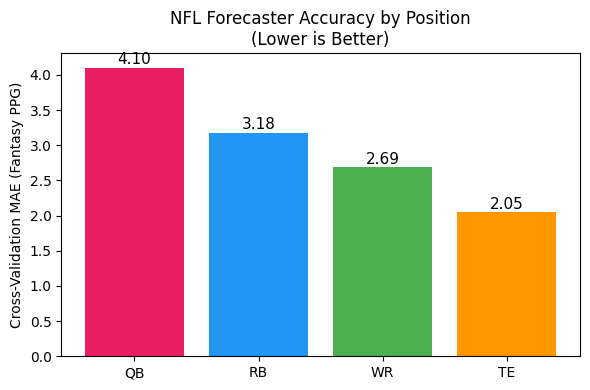

In [20]:
cv_maes = {pos: m["cv_mae"] for pos, (_, m) in all_forecasters.items()}
fig, ax = plt.subplots(figsize=(6, 4))
positions = list(cv_maes.keys())
maes = [cv_maes[p] for p in positions]
bars = ax.bar(positions, maes, color=["#E91E63", "#2196F3", "#4CAF50", "#FF9800"])
ax.set_ylabel("Cross-Validation MAE (Fantasy PPG)")
ax.set_title("NFL Forecaster Accuracy by Position\n(Lower is Better)")
for bar, mae in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{mae:.2f}", ha='center', fontsize=11)
plt.tight_layout()
plt.savefig("artifacts/cv_mae_by_position.png", dpi=150)
plt.show()

## Injury Risk Model

In [21]:
print("\nTraining Injury Risk Classifier...")
injury_model = InjuryRiskModel()
injury_metrics = injury_model.train_with_tracking(df_all, params={"model": "LogisticRegression"})
injury_model.save()
print(f"\nInjury model metrics:")
for k, v in injury_metrics.items():
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

01:15:48 [INFO] models.injury_risk: [InjuryRisk] Training on 2862 samples, 91 injured (3.2%)



Training Injury Risk Classifier...


01:15:48 [INFO] models.injury_risk: [InjuryRisk] CV AUC: 0.679, CV Brier: 0.225
01:15:48 [INFO] models.base: Model saved to /Users/sandeeptiwari/Desktop/dynasty-ai-engine/models/registry/injury_risk_classifier.joblib
01:15:48 [INFO] models.base: [injury_risk_classifier] Training complete. Metrics: {'cv_auc': 0.6785786299314706, 'cv_brier': 0.22451144306667303, 'train_auc': 0.6955516515242246, 'train_brier': 0.03046764639460174, 'train_avg_precision': 0.060838022465197525, 'n_train': 2862, 'positive_rate': 0.03179594689028651}
01:15:48 [INFO] models.base: Model saved to /Users/sandeeptiwari/Desktop/dynasty-ai-engine/models/registry/injury_risk_classifier.joblib



Injury model metrics:
  cv_auc: 0.679
  cv_brier: 0.225
  train_auc: 0.696
  train_brier: 0.030
  train_avg_precision: 0.061
  n_train: 2862
  positive_rate: 0.032


#### Calibration Plot

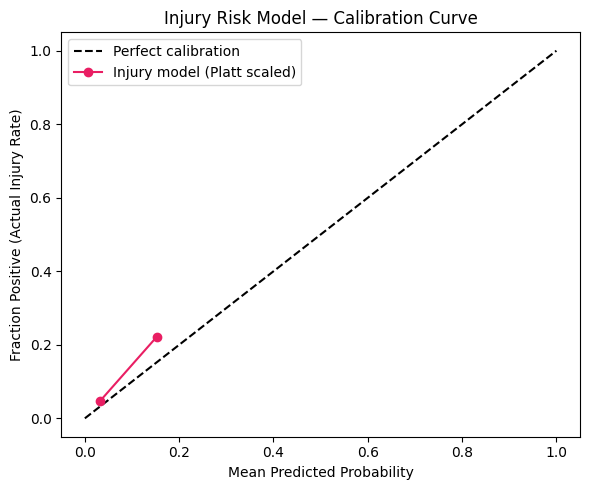


Calibration plot saved. A well-calibrated model tracks the dashed line.


In [22]:
from sklearn.calibration import calibration_curve
df_with_target = df_all.copy()
df_with_target["injured_binary"] = (df_with_target["games_missed_last_season"] >= 4).astype(int)

X_test = df_with_target[[c for c in injury_model._feature_cols if c in df_with_target]].fillna(0)
y_test = df_with_target["injured_binary"]
probs = injury_model._calibrated.predict_proba(X_test)[:, 1]

frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=8)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.plot(mean_pred, frac_pos, "o-", color="#E91E63", label="Injury model (Platt scaled)")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction Positive (Actual Injury Rate)")
ax.set_title("Injury Risk Model — Calibration Curve")
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/injury_calibration.png", dpi=150)
plt.show()
print("\nCalibration plot saved. A well-calibrated model tracks the dashed line.")

## College Translator

In [32]:
print("\nTraining College-to-NFL Translator for WR...")
wr_translator = CollegeToNFLTranslator("WR")

# Use rookie seasons only (years_exp <= 2)
college_df = df_all[
    (df_all["position"] == "WR") &
    (df_all["years_experience"].fillna(99) <= 3) &
    (df_all["dominator_rating"].notna())
].copy()
print(f"  {len(college_df)} rookie WR seasons with college data")

if len(college_df) >= 30:
    college_metrics = wr_translator.train_with_tracking(
        college_df, params={"position": "WR"}
    )
    wr_translator.save()
    print(f"  CV MAE: {college_metrics.get('cv_mae', 'N/A'):.2f} PPG")

    coef_df = wr_translator.get_coefficient_summary()
    print("\nCollege Translator — Standardized Coefficients:")
    print(coef_df.to_string())
else:
    print("  Not enough data — run pipeline --backfill first.")

08:45:20 [WARNING] models.college_translator: [WR] Only 30 prospects — need 40. Predictions will be low quality.
08:45:20 [INFO] models.college_translator: [WR] Training on 30 historical prospects, 13 features.
08:45:20 [INFO] models.college_translator: [WR] Ridge selected alpha=50.0
08:45:20 [INFO] models.college_translator: [WR] Top coefficients:
                  feature  coefficient
10          vertical_jump     0.497728
12  draft_pick_normalized     0.438121
8             speed_score     0.309276
11            draft_round    -0.216688
4            breakout_age    -0.129707
08:45:20 [INFO] models.base: Model saved to /Users/sandeeptiwari/Desktop/dynasty-ai-engine/models/registry/college_translator_wr.joblib
08:45:20 [INFO] models.base: [college_translator_wr] Training complete. Metrics: {'cv_mae': 2.0294135628720062, 'train_mae': 1.7916065893032866, 'train_rmse': 2.2640153623218833, 'best_alpha': 50.0, 'n_train': 30, 'n_features': 13}
08:45:20 [INFO] models.base: Model saved to /Us


Training College-to-NFL Translator for WR...
  30 rookie WR seasons with college data
  CV MAE: 2.03 PPG

College Translator — Standardized Coefficients:
                    feature  std_coefficient
10            vertical_jump         0.497728
12    draft_pick_normalized         0.438121
8               speed_score         0.309276
11              draft_round        -0.216688
4              breakout_age        -0.129707
9                forty_yard        -0.120141
3   college_conference_tier         0.062651
2      college_tds_per_game        -0.060885
6               sparq_score        -0.052768
7   relative_athletic_score         0.033078
0          dominator_rating        -0.022912
5          age_at_nfl_entry        -0.014290
1    college_yards_per_game        -0.001969


## Inference

In [44]:
print("\n=== End-to-end inference example ===")
store = ModelStore()
store.load_all()

# Use the model store's smart router
# sample_player = df_all.sort_values("fantasy_ppg_ppr", ascending=False).iloc[0]
sample_player = df_all.sample(1).iloc[0]
player_name = sample_player.get("player_name", "Unknown")
player_id = str(sample_player["player_id"])
season = int(sample_player["season"]) + 1

print(f"\nPredicting for: {player_name} (season: {season})")
result = store.predict_player(player_id, season, sample_player, player_name)

if result:
    print(result.to_prose())

print("\nTraining notebook complete.")

09:38:48 [INFO] registry.model_store: Loading dynasty-scout models from disk...
09:38:48 [INFO] registry.model_store:   ✓ NFL Forecaster (QB)
09:38:48 [INFO] registry.model_store:   ✓ NFL Forecaster (RB)



=== End-to-end inference example ===


09:38:48 [INFO] registry.model_store:   ✓ NFL Forecaster (WR)
09:38:48 [INFO] registry.model_store:   ✓ NFL Forecaster (TE)
09:38:48 [INFO] registry.model_store:   ✓ Injury Risk Classifier
09:38:48 [INFO] registry.model_store:   ✓ College Translator (WR)
09:38:48 [WARNING] registry.model_store: 
Some models not found (run train_all() first): ['College Translator QB not found', 'College Translator RB not found', 'College Translator TE not found']



Predicting for: JaMycal Hasty (season: 2022)
JaMycal Hasty (RB) — nfl_forecaster_rb projection for 2022:
  Projected PPG (PPR): 4.6 [floor 3.4 / ceiling 5.9]
  Confidence: MEDIUM
  Positive factors: WOPR 1.62 (+0.5 pts); PPG trend (slope) (missing) (+0.1 pts); Target share 95% (+0.1 pts); Yards/target 5.41 (+0.1 pts)
  Risk factors: Snap % 19% (-1.6 pts); Carries/game 1.60 (-1.1 pts); NFL experience (yrs) 6.00 (-0.6 pts); Targets/game 2.90 (-0.4 pts)
  Historical comps: JaMycal Hasty 2021 (99% match), Cordarrelle Patterson 2018 (98% match), Kenneth Gainwell 2022 (97% match)

Training notebook complete.


In [42]:
df_all[df_all["season"].isna()]

,id,player_id,season,position,player_type,fantasy_ppg_ppr,fantasy_ppg_last_season,fantasy_ppg_2yr_avg,fantasy_ppg_3yr_avg,fantasy_ppg_trend,games_played,career_games,target_share,air_yards_share,wopr,snap_pct,snap_pct_trend,carries_per_game,targets_per_game,yards_per_target,yards_per_carry,yards_after_catch_per_rec,racr,epa_per_play,cpoe,ryoe_per_att,separation_avg,avg_yac_above_expectation,games_missed_last_season,games_missed_2yr_total,injury_risk_score,soft_tissue_injury_flag,acl_history_flag,concussion_history_count,injury_designation_count,age,age_at_nfl_entry,years_experience,age_vs_position_peak,team_pass_rate,team_pass_rate_neutral,team_plays_per_game,team_pass_attempts,team_points_per_game,offensive_line_rank,new_team_flag,new_oc_flag,scheme_fit_score,dominator_rating,breakout_age,college_yards_per_game,college_tds_per_game,college_conference_tier,draft_round,draft_pick_normalized,sparq_score,relative_athletic_score,speed_score,height_weight_bmi,forty_yard,vertical_jump,fantasy_ppg_next_season,player_name,nfl_team,sleeper_id,draft_year
